<a href="https://colab.research.google.com/github/thaynnayara/ADS-Inteligencia_Artificial/blob/main/Lista2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Objetivo

Desenvolver um modelo de classificação binária utilizando Regressão Logística para prever se um empréstimo será aprovado ou não.

##Imports

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import classification_report

##Carregamento dos Dados

In [4]:
df = pd.read_csv('dataset_emprestimo_aprovacao.csv')

print(df.head(10))

#verificar informações gerais
print(df.info())

   renda_mensal  score_credito  dividas_ativas  emprestimo_aprovado
0       5493.43            480               4                    0
1       4223.47            600               5                    0
2       5795.38            609               5                    1
3       7546.06            554               1                    1
4       4031.69            631               0                    1
5       4031.73            698               1                    1
6       1773.00            808               0                    1
7       6034.87            671               1                    1
8       3561.05            681               0                    1
9       5585.12            641               2                    1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   renda_mensal         100 non-null    float64

##Análise Exploratória

In [5]:
df.describe()

,renda_mensal,score_credito,dividas_ativas,emprestimo_aprovado
count,100.000000,100.000000,100.000000,100.00000
mean,4596.775500,651.220000,1.990000,0.79000
std,2623.031756,109.977921,1.690705,0.40936
min,1200.000000,420.000000,0.000000,0.00000
25%,3274.882500,553.500000,1.000000,1.00000
50%,4312.340000,660.000000,2.000000,1.00000
75%,5541.177500,725.500000,3.000000,1.00000
max,19546.000000,900.000000,8.000000,1.00000


In [6]:
df.corr()

,renda_mensal,score_credito,dividas_ativas,emprestimo_aprovado
renda_mensal,1.000000,-0.070066,0.135866,-0.058644
score_credito,-0.070066,1.000000,0.003326,0.242901
dividas_ativas,0.135866,0.003326,1.000000,-0.207389
emprestimo_aprovado,-0.058644,0.242901,-0.207389,1.000000


emprestimo_aprovado
1    79
0    21
Name: count, dtype: int64
emprestimo_aprovado
1    79.0
0    21.0
Name: proportion, dtype: float64


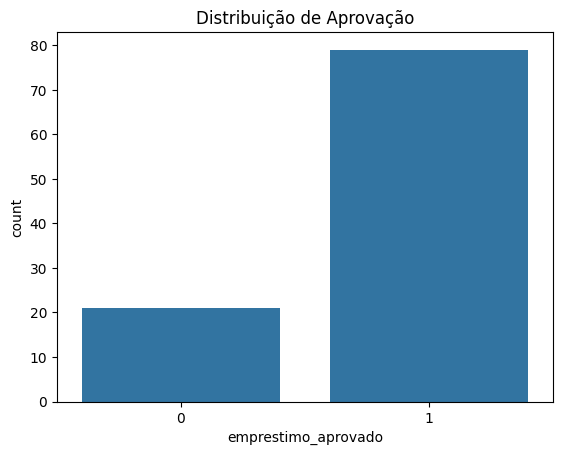

In [7]:
#verificando a quantidade exata e o percentual
print(df['emprestimo_aprovado'].value_counts())
print(df['emprestimo_aprovado'].value_counts(normalize=True) * 100)

#visualizando com Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='emprestimo_aprovado', data=df)
plt.title('Distribuição de Aprovação')
plt.show()

#Analise (Thaynná): 79% dos casos são de empréstimos aprovados. Com isso o modelo terá muitos exemplos de "sim" para aprender do que de "não", o que pode causar um viés.

In [8]:
#Analisando media
#agrupamos por aprovação e calculando a média das outras colunas
analise_media = df.groupby('emprestimo_aprovado').mean()
print(analise_media)

#Analise (Thaynná): o score_credito se mostra um fator importante, sendo decisivo

                     renda_mensal  score_credito  dividas_ativas
emprestimo_aprovado                                             
0                     4893.631429     599.666667        2.666667
1                     4517.864430     664.924051        1.810127


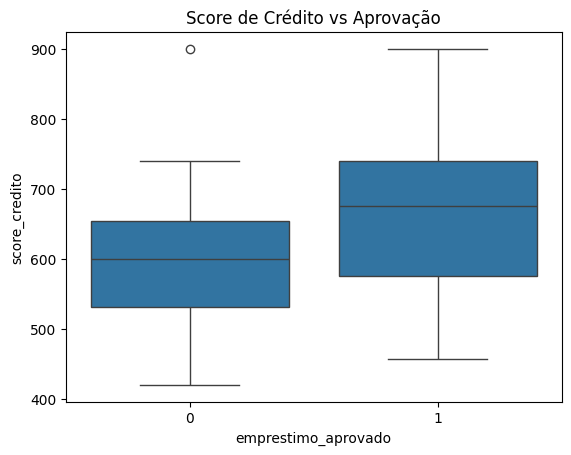

In [9]:
#Boxplot
sns.boxplot(x='emprestimo_aprovado', y='score_credito', data=df)
plt.title('Score de Crédito vs Aprovação')
plt.show()

#Analise (Thaynná): Aqui temos a confirmação que de fato o score_credito influencia na aprovação de crédito

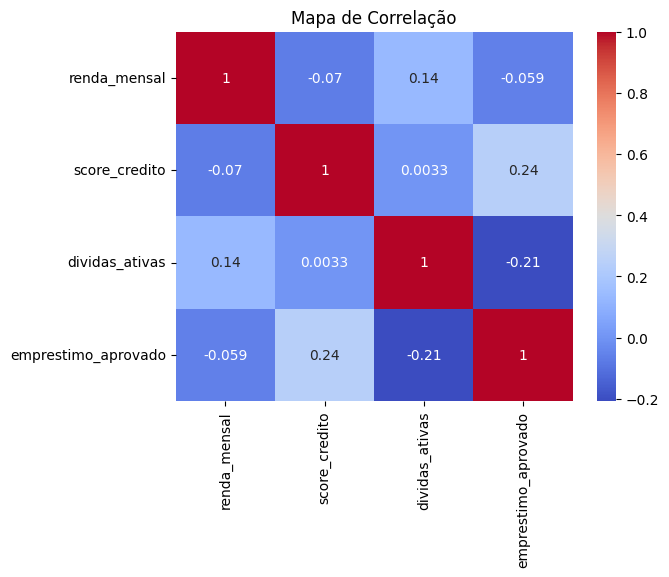

In [10]:
#Entender a relação de todas as variáveis

correlacao = df.corr()

#Mapa de Calor
sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Mapa de Correlação')
plt.show()

#Análise (Thaynná): score_credito é positivo (0.24): quanto mais score, mais aprovação.O valor com dividas_ativas é negativo (-0.21): quanto mais dívidas, menos aprovação.

##Preparação dos Dados

In [11]:
#variáveis independente e alvo
x = df.drop('emprestimo_aprovado', axis=1)
y = df['emprestimo_aprovado']

# Dividindo em Treino (80%) e Teste (20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##Treinamento do Modelo

In [12]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

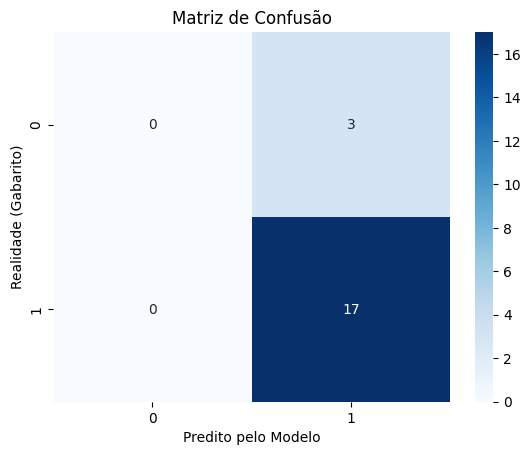

In [13]:
#Gerando as previsões
y_pred = model.predict(x_test)

#matriz
cm = confusion_matrix(y_test, y_pred)

#Visualizando de forma amigável
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito pelo Modelo')
plt.ylabel('Realidade (Gabarito)')
plt.title('Matriz de Confusão')
plt.show()

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.2%}")

Acurácia: 85.00%


In [15]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Precisão: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Precisão: 85.00%
Recall: 100.00%


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.85      1.00      0.92        17

    accuracy                           0.85        20
   macro avg       0.42      0.50      0.46        20
weighted avg       0.72      0.85      0.78        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
